Image dimensions: 421 x 652

Source points:
[[100. 100.]
 [300. 100.]
 [100. 300.]]

Destination points:
[[120.  80.]
 [350. 120.]
 [100. 350.]]

Solved affine matrix:
[[  1.15  -0.1   15.  ]
 [  0.2    1.35 -75.  ]]

Saved: task7_fixed_glitched_photo.jpg


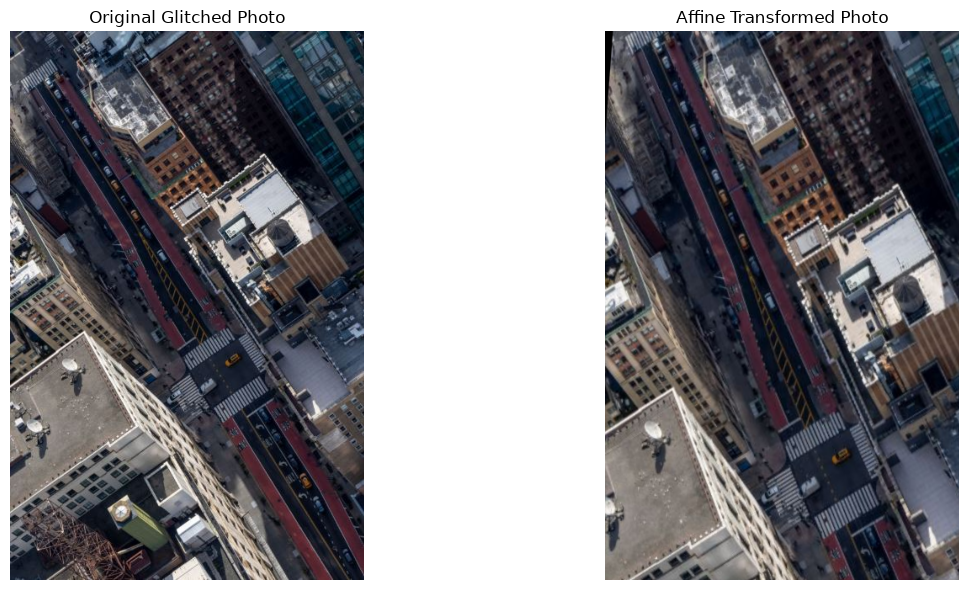

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "glitched_photo.jpg"
output_path = "task7_fixed_glitched_photo.jpg"

# ---------------------------------------------------------
# SOURCE POINTS
# Replace these with the 3 points from your lab image.
#
# Format:
# [[x1, y1],
#  [x2, y2],
#  [x3, y3]]
# ---------------------------------------------------------
src = np.array([
    [100, 100],
    [300, 100],
    [100, 300]
], dtype=np.float32)

# ---------------------------------------------------------
# DESTINATION POINTS
# Replace these with the corresponding target points.
#
# Each destination point corresponds to the source point
# at the same position.
# ---------------------------------------------------------
dst = np.array([
    [120, 80],
    [350, 120],
    [100, 350]
], dtype=np.float32)

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

h, w = img.shape[:2]

print("Image dimensions:", w, "x", h)

print("\nSource points:")
print(src)

print("\nDestination points:")
print(dst)

# ---------------------------------------------------------
# Construct the system of equations
#
# X = a*x + b*y + tx
# Y = c*x + d*y + ty
#
# Unknowns:
# [a, b, tx, c, d, ty]
# ---------------------------------------------------------
A = []
B = []

for (x, y), (X, Y) in zip(src, dst):

    A.append([x, y, 1, 0, 0, 0])
    A.append([0, 0, 0, x, y, 1])

    B.append(X)
    B.append(Y)

A = np.array(A, dtype=np.float64)
B = np.array(B, dtype=np.float64)

# ---------------------------------------------------------
# Solve the six unknowns
# ---------------------------------------------------------
p = np.linalg.solve(A, B)

# Convert solution into a 2x3 affine matrix
M = p.reshape(2, 3).astype(np.float32)

print("\nSolved affine matrix:")
print(M)

# ---------------------------------------------------------
# Apply affine transformation
# ---------------------------------------------------------
result = cv2.warpAffine(
    img,
    M,
    (w, h)
)

# ---------------------------------------------------------
# Save result
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display original and transformed image in Jupyter
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Glitched Photo")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Affine Transformed Photo")
plt.axis("off")

plt.tight_layout()
plt.show()
